In [21]:
!pip install numpy pandas scipy

In [22]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
base_path ='/content/drive/MyDrive/Apex/'

In [25]:
import os
os.listdir('/content/drive/MyDrive/Apex')

['Wins.csv',
 'Games.csv',
 'Damage_dealt.csv',
 'Damage_taken.csv',
 'Damage_ratio.csv',
 'Deaths.csv',
 'Assists.csv',
 'Knocks.csv',
 'Ring_damage.csv',
 'Kills.csv']

In [26]:
kills = pd.read_csv(base_path + 'Kills.csv')
wins = pd.read_csv(base_path + 'Wins.csv')
games = pd.read_csv(base_path + 'Games.csv')
damage_taken = pd.read_csv(base_path + 'Damage_taken.csv')
damage_dealt = pd.read_csv(base_path + 'Damage_dealt.csv')
deaths = pd.read_csv(base_path + 'Deaths.csv')
assists = pd.read_csv(base_path + 'Assists.csv')
knocks = pd.read_csv(base_path + 'Knocks.csv')
ring_dmg = pd.read_csv(base_path + 'Ring_damage.csv')

In [27]:
df_algs = kills[['player_name','kills','current_team']].merge(damage_dealt[['player_name','damage dealt']],on='player_name')\
          .merge(damage_taken[['player_name','damage taken']],on='player_name')\
          .merge(deaths[['player_name','deaths']],on='player_name')\
          .merge(assists[['player_name','assists']],on='player_name')\
          .merge(knocks[['player_name','knockdowns']],on='player_name')\
          .merge(ring_dmg[['player_name','ring damage']],on='player_name')\
          .merge(wins[['player_name','wins']],on='player_name')\
          .merge(games[['player_name','games']],on='player_name')


In [28]:
df_algs.iloc[0]

,0
player_name,ImperialHal
kills,1952.0
current_team,Team Falcons
damage dealt,488769.0
damage taken,400941.0
deaths,506.0
assists,738.0
knockdowns,1119.0
ring damage,20685.0
wins,89.0


In [29]:

df_algs['kills_pg']      = df_algs['kills']        / df_algs['games']
df_algs['damage_pg']     = df_algs['damage dealt'] / df_algs['games']
df_algs['deaths_pg']     = df_algs['deaths']       / df_algs['games']
df_algs['assists_pg']    = df_algs['assists']      / df_algs['games']
df_algs['knockdowns_pg'] = df_algs['knockdowns']   / df_algs['games']
df_algs['ring_dmg_pg']   = df_algs['ring damage']  / df_algs['games']
df_algs['win_rate']      = df_algs['wins']         / df_algs['games']


df_algs['survival_rate'] = (1 - df_algs['deaths_pg']).clip(0, 1)

df_algs['knock_eff'] = (df_algs['kills'] / (df_algs['knockdowns'] + 1)).clip(0, 1)


fill_cols = [
    'kills_pg', 'damage_pg', 'deaths_pg', 'assists_pg',
    'knockdowns_pg', 'ring_dmg_pg', 'win_rate',
    'survival_rate', 'knock_eff', 'damage_diff'
]

print(f"{'Column':<20} {'NaNs filled':<15} {'Filled with (median)'}")
print("-" * 52)
for col in fill_cols:
    if col not in df_algs.columns:
        continue
    n_nan  = df_algs[col].isna().sum()
    median = df_algs[col].median()
    df_algs[col] = df_algs[col].fillna(median)
    print(f"{col:<20} {n_nan:<15} {median:.3f}")

Column               NaNs filled     Filled with (median)
----------------------------------------------------
kills_pg             4               1.069
damage_pg            302             271.047
deaths_pg            302             0.534
assists_pg           309             0.398
knockdowns_pg        306             0.524
ring_dmg_pg          316             21.096
win_rate             122             0.054
survival_rate        302             0.466
knock_eff            306             1.000


In [30]:
df_algs['composite'] = (
    df_algs['kills_pg'].rank(pct=True)      * 0.25+
    df_algs['damage_pg'].rank(pct=True)     * 0.25 +
    df_algs['win_rate'].rank(pct=True)      * 0.25+
    df_algs['survival_rate'].rank(pct=True) * 0.25
)

MIN_GAMES = 50
df_clean = df_algs[df_algs['games'] >= MIN_GAMES].copy().reset_index(drop=True)

print(f"Players with {MIN_GAMES}+ games: {len(df_clean)}")
print()

print("Stat ranges after cleaning:")
print(f"  kills_pg:      {df_clean['kills_pg'].min():.2f} — {df_clean['kills_pg'].max():.2f}")
print(f"  damage_pg:     {df_clean['damage_pg'].min():.0f} — {df_clean['damage_pg'].max():.0f}")
print(f"  survival_rate: {df_clean['survival_rate'].min():.2f} — {df_clean['survival_rate'].max():.2f}  ← must stay 0–1")
print(f"  win_rate:      {df_clean['win_rate'].min():.3f} — {df_clean['win_rate'].max():.3f}")
print()

print("Top 10 by composite score:")
df_clean.nlargest(20, 'composite')[
    ['player_name', 'current_team', 'games', 'kills_pg', 'damage_pg', 'win_rate', 'composite']
].round(3)

Players with 50+ games: 883

Stat ranges after cleaning:
  kills_pg:      0.32 — 4.80
  damage_pg:     4 — 816
  survival_rate: 0.00 — 0.98  ← must stay 0–1
  win_rate:      0.005 — 0.179

Top 10 by composite score:


,player_name,current_team,games,kills_pg,damage_pg,win_rate,composite
42,SangJoon,CrazyRaccoon,646,1.704,442.743,0.118,0.836
105,Yuki,Alliance,367,2.150,417.362,0.104,0.835
20,obly,ENTER FORCE.36,670,1.858,368.110,0.142,0.833
66,NAFEN,NRG,341,2.818,384.818,0.097,0.832
157,Metro,Team RRQ,224,2.777,433.607,0.085,0.829
259,Yanzz,PRYANIKI,221,1.905,328.086,0.109,0.815
283,yJely,HUSS,255,1.541,405.914,0.125,0.814
39,KaronPe,CrazyRaccoon,558,2.013,324.667,0.109,0.810
36,Dezignful,Source Gaming,533,2.124,329.649,0.109,0.808
77,Roieee_o,Relove DCG,565,1.598,412.209,0.097,0.807


In [31]:
def build_player_model(row):

    confidence           = min(row['games'] / 100, 1.5)


    uncertainty_mult     = 1 / confidence

    def make_dist(mean, base_frac):

        std  = mean * base_frac * uncertainty_mult
        return {'mean': mean, 'std': std}

    return {
        'name':     row['player_name'],
        'team':     row['current_team'] if pd.notna(row['current_team']) else '—',
        'games':    row['games'],
        'kills':    make_dist(row['kills_pg'],     base_frac=0.40),
        'damage':   make_dist(row['damage_pg'],    base_frac=0.35),
        'survival': {
            'mean': float(np.clip(row['survival_rate'], 0.01, 0.99)),
            'std':  0.15 * uncertainty_mult
        },
        'win_rate': row['win_rate'],
    }

contestants = df_clean.nlargest(30, 'composite').reset_index(drop=True)
player_models = [build_player_model(row) for _, row in contestants.iterrows()]

p = player_models[0]
print(f"Example: {p['name']} ({p['team']}, {p['games']} games)")
print(f"  kills   → Normal(mean={p['kills']['mean']:.2f},  std={p['kills']['std']:.2f})")
print(f"  damage  → Normal(mean={p['damage']['mean']:.0f}, std={p['damage']['std']:.0f})")
print(f"  survival→ Normal(mean={p['survival']['mean']:.2f}, std={p['survival']['std']:.2f})")

Example: SangJoon (CrazyRaccoon, 646 games)
  kills   → Normal(mean=1.70,  std=0.45)
  damage  → Normal(mean=443, std=103)
  survival→ Normal(mean=0.48, std=0.10)


In [32]:

PLACEMENT_POINTS = {
    1: 12, 2: 9,  3: 7,  4: 5,  5: 4,
    6: 3,  7: 3,  8: 2,  9: 2,  10: 2,
    11: 1, 12: 1, 13: 1, 14: 1, 15: 1
    # 16–20: 0 points
}
KILL_CAP = 6

def simulate_one_game(models):
    results = []

    for p in models:

        kills  = max(0, np.random.normal(p['kills']['mean'],    p['kills']['std']))
        damage = max(0, np.random.normal(p['damage']['mean'],   p['damage']['std']))
        surv   = np.clip(np.random.normal(p['survival']['mean'], p['survival']['std']), 0, 1)


        perf = damage * 0.5 + surv * 300 + kills * 80

        results.append({'name': p['name'], 'kills': kills, 'perf': perf})

    results.sort(key=lambda x: x['perf'], reverse=True)

    game_points = {}
    for i, r in enumerate(results):
        place_pts = PLACEMENT_POINTS.get(i + 1, 0)
        kill_pts  = min(int(r['kills']), KILL_CAP)
        game_points[r['name']] = place_pts + kill_pts

    return game_points

result = simulate_one_game(player_models)
print("Sample game result:")
for name, pts in sorted(result.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {name:<25} {pts:>3} pts  {'█' * pts}")

Sample game result:
  kakigoori7                 15 pts  ███████████████
  ImperialHal                11 pts  ███████████
  izzxxv                      9 pts  █████████
  Unlucky                     8 pts  ████████
  Wxltzy                      6 pts  ██████
  Prycyy                      5 pts  █████
  Sweet                       5 pts  █████
  YukaF                       4 pts  ████
  Hakis                       4 pts  ████
  Metro                       4 pts  ████


In [33]:
def run_monte_carlo(models, n_games=6, n_simulations=10_000):
    names = [p['name'] for p in models]

    win_counts  = {n: 0 for n in names}
    top3_counts = {n: 0 for n in names}
    all_scores  = {n: [] for n in names}

    for sim in range(n_simulations):
        if sim % 2000 == 0:
            print(f"  {sim:>6,} / {n_simulations:,}...", end='\r')


        total = {n: 0 for n in names}
        for _ in range(n_games):
            game = simulate_one_game(models)
            for name, pts in game.items():
                total[name] += pts


        ranked = sorted(total.items(), key=lambda x: x[1], reverse=True)
        win_counts[ranked[0][0]] += 1

        for name, _ in ranked[:3]:
            top3_counts[name] += 1

        for name, pts in total.items():
            all_scores[name].append(pts)


    results = pd.DataFrame({
        'player':    names,
        'team':      [p['team'] for p in models],
        'games':     [p['games'] for p in models],


        'win_prob':  [win_counts[n]  / n_simulations for n in names],
        'top3_prob': [top3_counts[n] / n_simulations for n in names],


        'avg_score': [round(np.mean(all_scores[n]), 1) for n in names],


        'score_std': [round(np.std(all_scores[n]), 1)  for n in names],
    }).sort_values('win_prob', ascending=False).reset_index(drop=True)

    return results, all_scores


results, all_scores = run_monte_carlo(player_models, n_games=6, n_simulations=10_000)
print()
results[['player', 'team', 'games', 'win_prob', 'top3_prob', 'avg_score', 'score_std']].head(15)

,player,team,games,win_prob,top3_prob,avg_score,score_std
0,Effect,AURORA,563,0.5835,0.8865,55.6,11.6
1,Ylariman,UNLIMIT,235,0.2254,0.6861,46.1,10.9
2,ImperialHal,Team Falcons,790,0.0850,0.4387,39.1,10.4
3,Ras,Crazy Raccoon,279,0.0535,0.3552,37.8,9.9
4,Metro,Team RRQ,224,0.0186,0.1945,32.5,9.1
5,kakigoori7,NOEZ FOXX,181,0.0092,0.1086,29.0,9.0
6,NAFEN,NRG,341,0.0084,0.1091,29.1,8.4
7,Zer0,Team Liquid,751,0.0084,0.0923,28.2,8.7
8,Unlucky,Alliance,710,0.0045,0.0580,26.0,8.2
9,Prycyy,Team RRQ,654,0.0023,0.0430,24.4,8.0


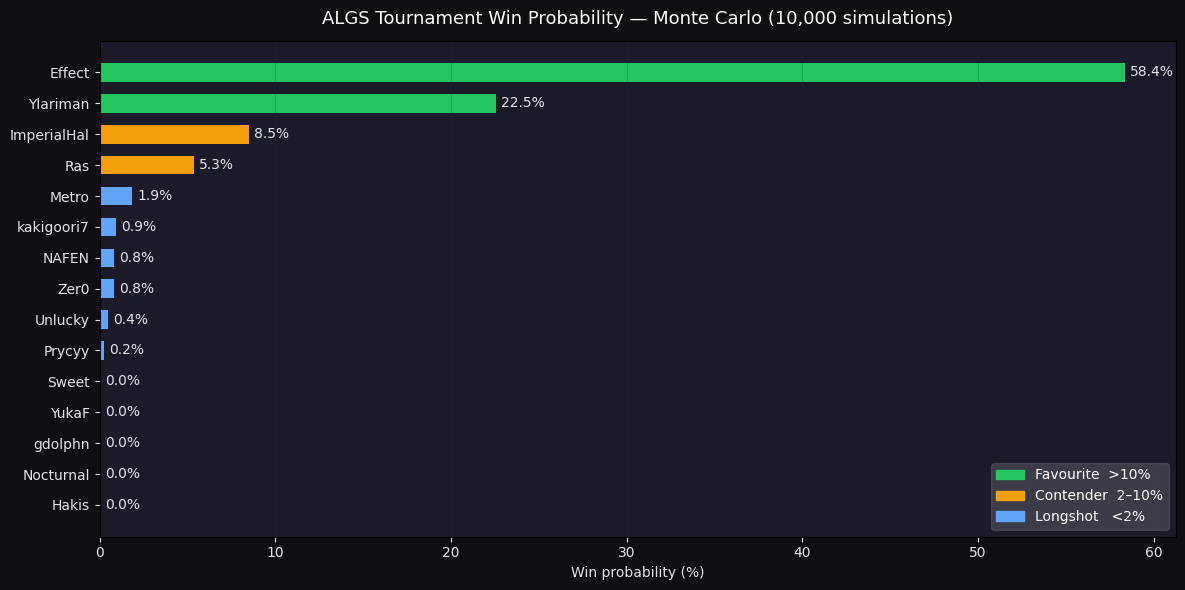

In [34]:
top15   = results.head(15)
colors  = ['#22c55e' if p >= 0.10 else '#f59e0b' if p >= 0.02 else '#60a5fa'
           for p in top15['win_prob']]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f13')
ax.set_facecolor('#1a1a28')

bars = ax.barh(top15['player'], top15['win_prob'] * 100,
               color=colors, edgecolor='none', height=0.6)

for bar, val in zip(bars, top15['win_prob']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center', color='#e2e2e8', fontsize=10)

ax.invert_yaxis()
ax.set_xlabel('Win probability (%)', color='#e2e2e8')
ax.set_title('ALGS Tournament Win Probability — Monte Carlo (10,000 simulations)',
             color='white', fontsize=13, pad=12)
ax.tick_params(colors='#e2e2e8')
ax.grid(axis='x', alpha=0.2, color='#2e2e42')

patches = [
    mpatches.Patch(color='#22c55e', label='Favourite  >10%'),
    mpatches.Patch(color='#f59e0b', label='Contender  2–10%'),
    mpatches.Patch(color='#60a5fa', label='Longshot   <2%'),
]
ax.legend(handles=patches, framealpha=0.15, labelcolor='white')
plt.tight_layout()
plt.show()